In [ ]:
%pip install numpy pandas scikit-learn matplotlib imbalanced-learn

In [1]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib
import imblearn

### Numerical/Theoretical -

Question - Linear SVM with soft margin (C=1.0) achieves 85% accuracy, three options:

1. Increase C to 100.0

2. Decrease C to 0.01

3. Remove the outlier points and retrain

Analyse each option by explaining:

- How each choice affects the optimisation objective and the resulting decision boundary

- The trade-off between bias and variance for each approach

Which option would you choose and why, considering both the mathematical implications and practical machine learning principles



1. 
    From the Soft SVM objective function shown in the Week 4 lecture slides page 25, we know that C controls the penalty for margin violations and misclassified points. Increasing C from 1 to 100 makes the penalty term more important, so the model becomes less tolerant of misclassification. Therefore, the SVM will try harder to correctly classify the potentially mislabeled outliers, causing the decision boundary to be more strongly affected by them, and resulting in a narrower margin.

    This reduces the bias because the model fits the training data more closely. However, it increases variance because the decision boundary becomes more sensitive to individual training points, especially the mislabeled outliers, which also increases the risk of overfitting.

2. 
    Decreasing C from 1 to 0.01 reduces the penalty for margin violations and misclassified points, so the model becomes more tolerant of misclassification. Therefore, the SVM is less likely to adjust the decision boundary significantly in order to correctly classify the potentially mislabeled outliers, which results in a wider and more stable margin.

    This approach increases the bias because the model allows more training errors instead of fitting the training data as closely. However, it reduces variance because the decision boundary becomes less sensitive to individual training points.

3. 
    Removing the outliers and retraining prevents these data points from influencing the optimization and decision boundary. If these points are truly mislabeled, removing them can reduce the effect of label noise and produce a decision boundary that better represents the underlying data.

    The effect on bias and variance therefore depends on whether these points are actually labeling errors. Since they only seem to be mislabeled, removing them without verification may increase bias by discarding valid but unusual observations. 

I would choose option 2 and decrease C to 0.01.

From the mathematical implication, decreasing C reduces the penalty for misclassification and allows the SVM to tolerate the potentially mislabeled outliers, so they have less influence on the decision boundary. In contrast, increases C (option 1) makes the decision boundary even more sensitive to these outliers.

From the practical machine learning principle, option 2 is also more appropriate because the outliers only seem to be mislabeled rather than being confirmed as labeling errors. Directly removes these data points (Option 3) may discard valid but unusual observations, while option 2 keeps all the data and reduces the influence of the suspected outliers.

### Coding -

In [2]:
from sklearn.datasets import fetch_kddcup99
kdd = fetch_kddcup99()

In [3]:
# Create DoS vs Non-DoS labels - 1 = DoS, 0 = Non-DoS

dos_attacks = [
    b'back.',
    b'land.',
    b'neptune.',
    b'pod.',
    b'smurf.',
    b'teardrop.'
]

y = np.isin(kdd.target, dos_attacks).astype(int)
X = kdd.data

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
X_train = pd.DataFrame(X_train, columns=kdd.feature_names)
X_test = pd.DataFrame(X_test, columns=kdd.feature_names)
categorical_features = ['protocol_type', 'service', 'flag']

In [6]:
# undersampling
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)

In [7]:
print("Before undersampling:", np.bincount(y_train))
print("After undersampling:", np.bincount(y_train_resampled))
print("Test set:", np.bincount(y_test))

Before undersampling: [ 82050 313166]
After undersampling: [82050 82050]
Test set: [20513 78292]


Here we can see that before undersampling, the training set contains 82,050 Non-DoS samples and 313,166 DoS samples, showing a clear class imbalance. After undersampling, both classes contain 82,050 samples, making the training set balanced. The test set remains unchanged because undersampling is only applied to the training set.

In [9]:
# one hot encoding for encoding categorical variables
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

X_train_encoded = preprocessor.fit_transform(X_train_resampled)
X_test_encoded = preprocessor.transform(X_test)

In [11]:
# scaling 
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

In [13]:
from sklearn.model_selection import train_test_split

X_train_svm, _, y_train_svm, _ = train_test_split(
    X_train_scaled,
    y_train_resampled,
    train_size=20000,
    random_state=42,
    stratify=y_train_resampled
)

In [14]:
print("SVM training set:", X_train_svm.shape)
print("Class distribution:", np.bincount(y_train_svm))

SVM training set: (20000, 117)
Class distribution: [10000 10000]


#### 1. Linear

In [15]:
from sklearn.svm import SVC
# train
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train_svm, y_train_svm)
# predict
y_pred_linear = svm_linear.predict(X_test_scaled)

In [16]:
from sklearn.metrics import accuracy_score, classification_report

print("Linear SVM Accuracy:", accuracy_score(y_test, y_pred_linear))
print("\nClassification Report:")
print(classification_report(y_test,y_pred_linear,target_names=['Non-DoS', 'DoS']))

Linear SVM Accuracy: 0.9948180760082992

Classification Report:
              precision    recall  f1-score   support

     Non-DoS       0.98      1.00      0.99     20513
         DoS       1.00      0.99      1.00     78292

    accuracy                           0.99     98805
   macro avg       0.99      1.00      0.99     98805
weighted avg       0.99      0.99      0.99     98805



The linear SVM achieves an accuracy of approximately 99.48%. The classification report also shows high precision, recall, and F1-scores for both Non-DoS and DoS classes, indicating that the model performs well on the original imbalanced test set.

#### 2. RBF

In [17]:
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train_svm, y_train_svm)

y_pred_rbf = svm_rbf.predict(X_test_scaled)

print("RBF SVM Accuracy:", accuracy_score(y_test, y_pred_rbf))
print("\nClassification Report:")
print(classification_report(y_test,y_pred_rbf,target_names=['Non-DoS', 'DoS']))

RBF SVM Accuracy: 0.9948383178988918

Classification Report:
              precision    recall  f1-score   support

     Non-DoS       0.98      1.00      0.99     20513
         DoS       1.00      0.99      1.00     78292

    accuracy                           0.99     98805
   macro avg       0.99      1.00      0.99     98805
weighted avg       0.99      0.99      0.99     98805



#### 3. Poly

In [18]:
# Polynomial kernel
svm_poly = SVC(kernel='poly')
svm_poly.fit(X_train_svm, y_train_svm)
y_pred_poly = svm_poly.predict(X_test_scaled)

print("Polynomial SVM Accuracy:", accuracy_score(y_test, y_pred_poly))
print("\nClassification Report:")
print(classification_report(y_test,y_pred_poly,target_names=['Non-DoS', 'DoS']))

Polynomial SVM Accuracy: 0.9946561408835585

Classification Report:
              precision    recall  f1-score   support

     Non-DoS       0.98      1.00      0.99     20513
         DoS       1.00      0.99      1.00     78292

    accuracy                           0.99     98805
   macro avg       0.99      1.00      0.99     98805
weighted avg       0.99      0.99      0.99     98805



#### 4. Sig

In [19]:
svm_sigmoid = SVC(kernel='sigmoid')
svm_sigmoid.fit(X_train_svm, y_train_svm)
y_pred_sigmoid = svm_sigmoid.predict(X_test_scaled)

print("Sigmoid SVM Accuracy:", accuracy_score(y_test, y_pred_sigmoid))
print("\nClassification Report:")
print(classification_report(y_test,y_pred_sigmoid,target_names=['Non-DoS', 'DoS']))

Sigmoid SVM Accuracy: 0.9868528920601184

Classification Report:
              precision    recall  f1-score   support

     Non-DoS       0.96      0.98      0.97     20513
         DoS       0.99      0.99      0.99     78292

    accuracy                           0.99     98805
   macro avg       0.98      0.98      0.98     98805
weighted avg       0.99      0.99      0.99     98805



#### Comparison

The Linear, RBF, and Polynomial kernels all achieve high accuracy of about 99.5%. The Sigmoid kernel has a lower accuracy of about 98.7%. The first three kernels also have very similar precision, recall, and F1-scores for both classes. The Sigmoid kernel performs worse, especially for the Non-DoS class. Its precision is 0.96, recall is 0.98, and F1-score is 0.97. The support values show that there are more DoS samples than Non-DoS samples in the test set.

#### Discussion

For the pros and cons of each kernel, the Linear kernel has the advantage of being simple and fast, but its disadvantage is that it can only learn a linear decision boundary. The RBF kernel can learn more complex and nonlinear patterns, which is its main advantage, but it takes more time and can be sensitive to parameters such as C and gamma. The Polynomial kernel also has the advantage of learning nonlinear patterns and interactions between features, but it becomes more complex when the degree increases. The Sigmoid kernel can also create a nonlinear decision boundary, but one of its disadvantages is that it can be sensitive to its parameters and data scaling. In our results, it performs worse than the other three kernels.

#### Pick two important features, train using only those two, visualize the decision boundary for linear and RBF only, and discuss your observations.

In [20]:
feature_names = preprocessor.get_feature_names_out()
coef = np.abs(svm_linear.coef_[0])

important_features = sorted(zip(feature_names, coef),key=lambda x: x[1],reverse=True)

for feature, importance in important_features[:15]:
    print(feature, importance)

remainder__wrong_fragment 3.0445959755061156
remainder__hot 2.0090780215066046
remainder__dst_host_diff_srv_rate 1.7147241391959387
remainder__is_guest_login 1.5092555484960983
remainder__diff_srv_rate 1.4686066903419066
remainder__srv_count 1.4068983093332639
cat__flag_b'RSTOS0' 1.3597123151629182
remainder__same_srv_rate 1.2056272620250352
cat__service_b'ecr_i' 1.1785701400762627
remainder__count 0.9042616824271004
remainder__serror_rate 0.8469903427106724
cat__flag_b'S0' 0.8259485587732838
remainder__dst_host_same_src_port_rate 0.7347072761550095
remainder__srv_rerror_rate 0.6695318968611126
remainder__dst_host_serror_rate 0.6670394338618395


Based on the absolute coefficients of the Linear SVM, `wrong_fragment` and `hot` have the two largest values among the original numerical features. So I would like to choose these two features as the important features for the following visualization.

In [21]:
selected_features = ['wrong_fragment', 'hot']

X_train_two = X_train_resampled[selected_features].astype(float)
X_test_two = X_test[selected_features].astype(float)
# scaling
scaler_two = MinMaxScaler()

X_train_two_scaled = scaler_two.fit_transform(X_train_two)
X_test_two_scaled = scaler_two.transform(X_test_two)

In [22]:
#subsample
X_vis, _, y_vis, _ = train_test_split(
    X_train_two_scaled,
    y_train_resampled,
    train_size=5000,
    random_state=42,
    stratify=y_train_resampled
)

print("Visualization sample:", X_vis.shape)
print("Class distribution:", np.bincount(y_vis))

Visualization sample: (5000, 2)
Class distribution: [2500 2500]


In [23]:
svm_linear_two = SVC(kernel='linear')
svm_rbf_two = SVC(kernel='rbf')

svm_linear_two.fit(X_vis, y_vis)
svm_rbf_two.fit(X_vis, y_vis)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [24]:
import matplotlib.pyplot as plt

def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.05, X[:, 0].max() + 0.05
    y_min, y_max = X[:, 1].min() - 0.05, X[:, 1].max() + 0.05
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=10, alpha=0.5)
    plt.xlabel('wrong_fragment')
    plt.ylabel('hot')
    plt.title(title)
    plt.show()

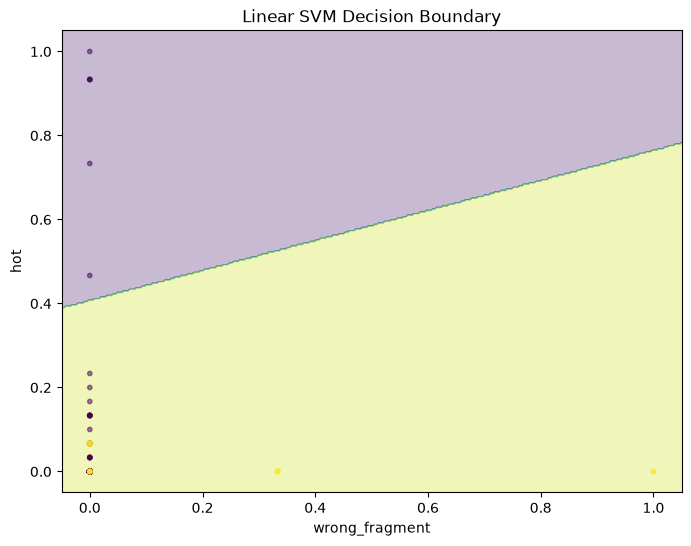

In [25]:
plot_decision_boundary(
    svm_linear_two,
    X_vis,
    y_vis,
    'Linear SVM Decision Boundary'
)

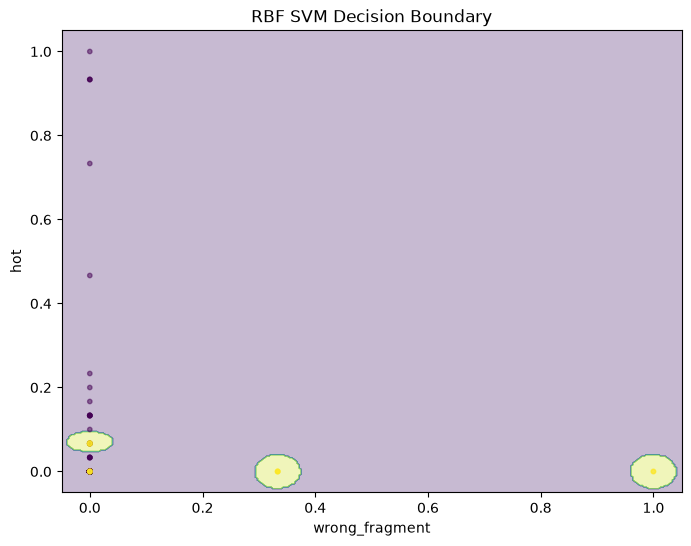

In [26]:
plot_decision_boundary(
    svm_rbf_two,
    X_vis,
    y_vis,
    'RBF SVM Decision Boundary'
)

From the two plots we can see that the Linear SVM creates a straight decision boundary and separates the two classes into two large regions. The RBF SVM creates more flexible boundaries and forms several small regions around some of the data points. This shows that the RBF kernel can follow local patterns that cannot be captured by a linear boundary. We can also see that many data points are overlap or are concentrated near zero when only these two features are used. Therefore, using only two features makes visualization possible, but it also removes much of the information from the original dataset.